   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)

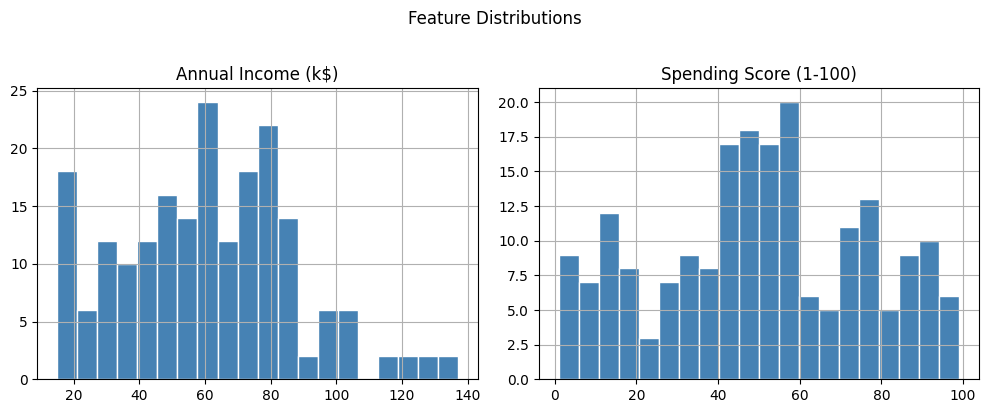

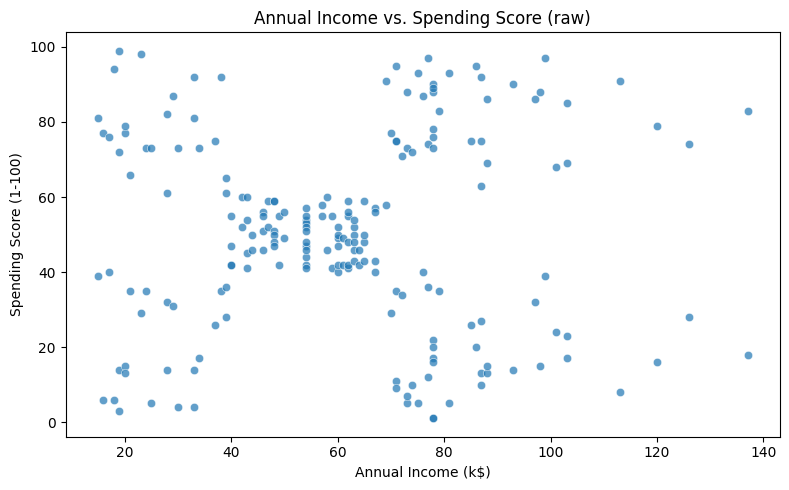

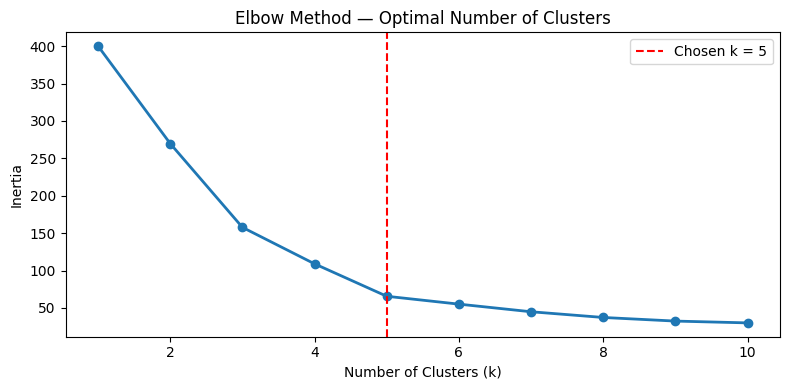


Cluster Profiles (mean values):
          Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                      55.3                    49.5
1                      86.5                    82.1
2                      25.7                    79.4
3                      88.2                    17.1
4                      26.3                    20.9

Segment sizes:
Segment
Cautious spenders — mid income, low spending       81
Target customers — high income, high spending      39
Conservative savers — high income, low spending    35
Average customers — mid income, mid spending       23
Impulsive spenders — low income, high spending     22
Name: count, dtype: int64

Business Insights
─────────────────
Target customers (high income, high spending)
  → Core revenue drivers. Prioritise retention and loyalty programmes.

Conservative savers (high income, low spending)
  → Biggest upselling opportunity. They have the budget — find out why
    they

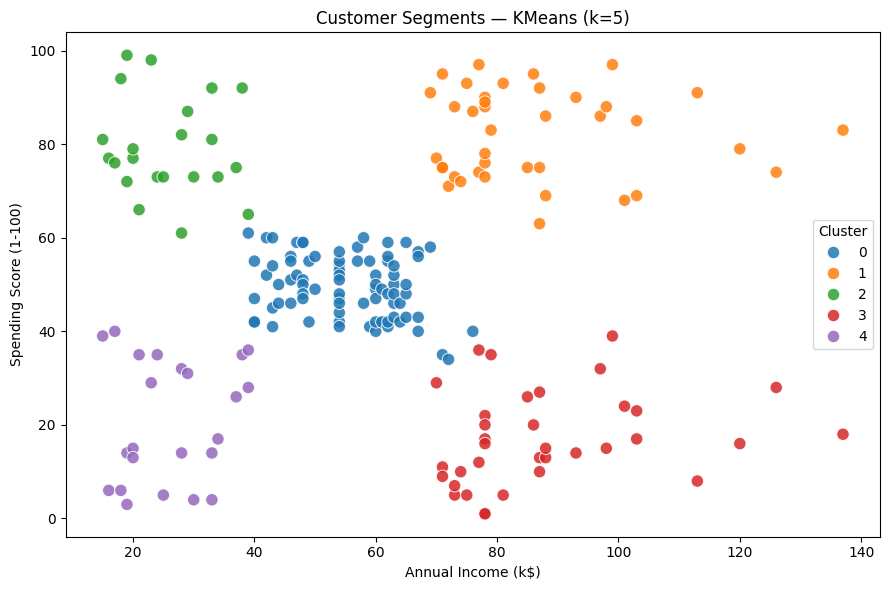

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load data
df = pd.read_csv("../data/mall_customers.csv")
print(df.head())

# Exploratory Data Analysis
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

# Visual EDA: distribution of the two features
df[["Annual Income (k$)", "Spending Score (1-100)"]].hist(
    bins=20, figsize=(10, 4), color="steelblue", edgecolor="white"
)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Raw scatter before clustering
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    alpha=0.7
)
plt.title("Annual Income vs. Spending Score (raw)")
plt.tight_layout()
plt.show()

# Feature selection & scaling
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
K_range = range(1, 11)  # test up to 10 clusters

for k in K_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o", linewidth=2)
plt.axvline(x=5, color="red", linestyle="--", label="Chosen k = 5")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.legend()
plt.tight_layout()
plt.show()

# Final model
model = KMeans(n_clusters=5, n_init=10, random_state=42)
df["Cluster"] = model.fit_predict(X_scaled)

# Cluster profiling
cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(1)
print("\nCluster Profiles (mean values):\n", cluster_summary)

# Business insights
cluster_labels = {
    0: "Cautious spenders — mid income, low spending",
    1: "Target customers — high income, high spending",
    2: "Impulsive spenders — low income, high spending",
    3: "Conservative savers — high income, low spending",
    4: "Average customers — mid income, mid spending"
}

df["Segment"] = df["Cluster"].map(cluster_labels)

print("\nSegment sizes:")
print(df["Segment"].value_counts())

print("""
Business Insights
─────────────────
Target customers (high income, high spending)
  → Core revenue drivers. Prioritise retention and loyalty programmes.

Conservative savers (high income, low spending)
  → Biggest upselling opportunity. They have the budget — find out why
    they're not spending it here.

Impulsive spenders (low income, high spending)
  → Respond well to promotions and discounts. Monitor for churn risk.

Cautious spenders (mid income, low spending)
  → Stable base. Could be activated with targeted incentives.

Average customers (mid income, mid spending)
  → Largest group typically. Benchmark segment for campaign performance.
""")

# Visualisation 
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=80,
    alpha=0.85
)
plt.title("Customer Segments — KMeans (k=5)")
plt.tight_layout()
plt.show()